In [1]:
import nibabel as nib 
import os 
import matplotlib.pyplot as plt 
import numpy as np 
import seaborn as sns 
from skimage.metrics import mean_squared_error as mse
from scipy.spatial.distance import jensenshannon
import pandas as pd
from tqdm import tqdm
from math import log10
from scipy.stats import entropy
from scipy.interpolate import make_interp_spline
from scipy.stats import rankdata
from scipy.stats import wilcoxon, ranksums, mannwhitneyu

# Stage two results for Philips kernels harmonized to B50f

In [2]:
def kl_div(dist1, dist2):
    dist1_hist, dist1_bins = np.histogram(dist1, bins = 10, density = True)
    dist2_hist, dist2_bins = np.histogram(dist2, bins = 10, density = True)
    
    kl = entropy(dist1_hist, dist2_hist)
    return kl

In [33]:
kl_btob50f = {}
kl_ctob50f = {}
kl_dtob50f = {}

b50f = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B30f_B50f/B50f_masked_emphysema/emph.csv")
b50f = b50f.sort_values(by='pid')
b = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B_D/B_emphysema/emph.csv")
b = b.sort_values(by='pid')
c = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/C_D/C_emphysema/emph.csv")
c = c.sort_values(by='pid')
d_c = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/C_D/D_emphysema/emph.csv")
d_c = d_c.sort_values(by='pid')

In [34]:
for i in tqdm(range(2,202,2)):
    btob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/BtoB50f_emphysema/epoch_{i}/emph.csv")
    btob50f = btob50f.sort_values(by='pid')
    ctob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/CtoB50f_emphysema/epoch_{i}/emph.csv")
    ctob50f = ctob50f.sort_values(by='pid')
    dtob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB50f_emphysema/epoch_{i}/emph.csv")
    dtob50f = dtob50f.sort_values(by='pid')

    kl_btob50f[i] = kl_div(btob50f['emph_score'], b50f['emph_score'])
    kl_ctob50f[i] = kl_div(ctob50f['emph_score'], b50f['emph_score'])
    kl_dtob50f[i] = kl_div(dtob50f['emph_score'], b50f['emph_score'])

100%|██████████| 100/100 [00:01<00:00, 78.21it/s]


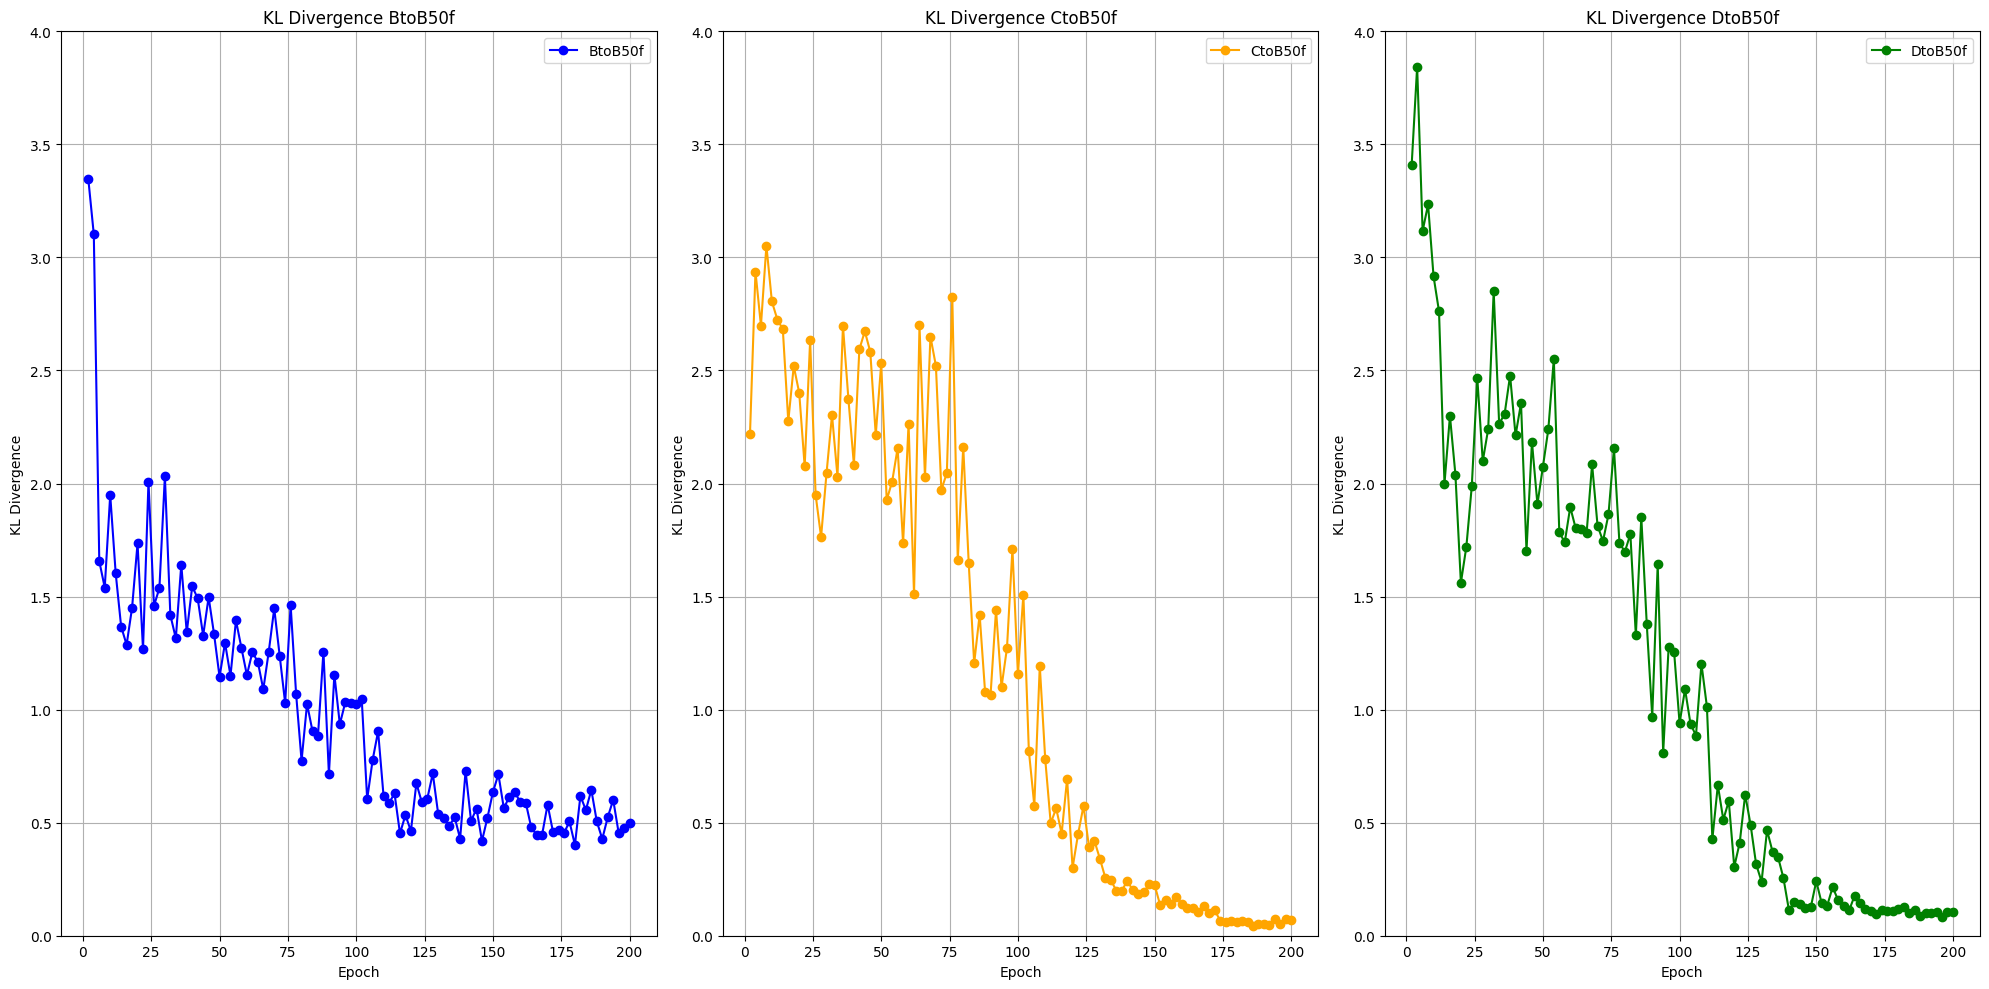

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(20, 10))
axes[0].plot(list(kl_btob50f.keys()), list(kl_btob50f.values()), label='BtoB50f', marker = 'o', color='blue')
axes[0].set_title('KL Divergence BtoB50f')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('KL Divergence')
axes[0].set_ylim(0, 4)
axes[0].legend()
axes[0].grid()

axes[1].plot(list(kl_ctob50f.keys()), list(kl_ctob50f.values()), label='CtoB50f', marker = 'o', color='orange')
axes[1].set_title('KL Divergence CtoB50f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_ylim(0, 4)
axes[1].legend()
axes[1].grid()

axes[2].plot(list(kl_dtob50f.keys()), list(kl_dtob50f.values()), label='DtoB50f', marker = 'o', color='green')
axes[2].set_title('KL Divergence DtoB50f')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_ylim(0, 4)
axes[2].legend()
axes[2].grid()

plt.tight_layout()
# fig.suptitle('KL Divergence for different paths', fontsize=16)
plt.show()

In [36]:
kl_btob50f_ranks = rankdata(list(kl_btob50f.values()))
kl_ctob50f_ranks = rankdata(list(kl_ctob50f.values()))
kl_dtob50f_ranks = rankdata(list(kl_dtob50f.values()))

kl_btob50f_rank = {list(kl_btob50f.keys())[i]: kl_btob50f_ranks[i] for i in range(len(kl_btob50f_ranks))}
kl_ctob50f_rank = {list(kl_ctob50f.keys())[i]: kl_ctob50f_ranks[i] for i in range(len(kl_ctob50f_ranks))}
kl_dtob50f_rank = {list(kl_dtob50f.keys())[i]: kl_dtob50f_ranks[i] for i in range(len(kl_dtob50f_ranks))}

kl_btob50f_rank = dict(sorted(kl_btob50f_rank.items()))
kl_ctob50f_rank = dict(sorted(kl_ctob50f_rank.items()))
kl_dtob50f_rank = dict(sorted(kl_dtob50f_rank.items()))


In [37]:
overall_stage_two_rank = {}
for key in kl_btob50f_rank.keys():
    overall_stage_two_rank[key] = (kl_btob50f_rank[key] + kl_ctob50f_rank[key] + kl_dtob50f_rank[key]) 

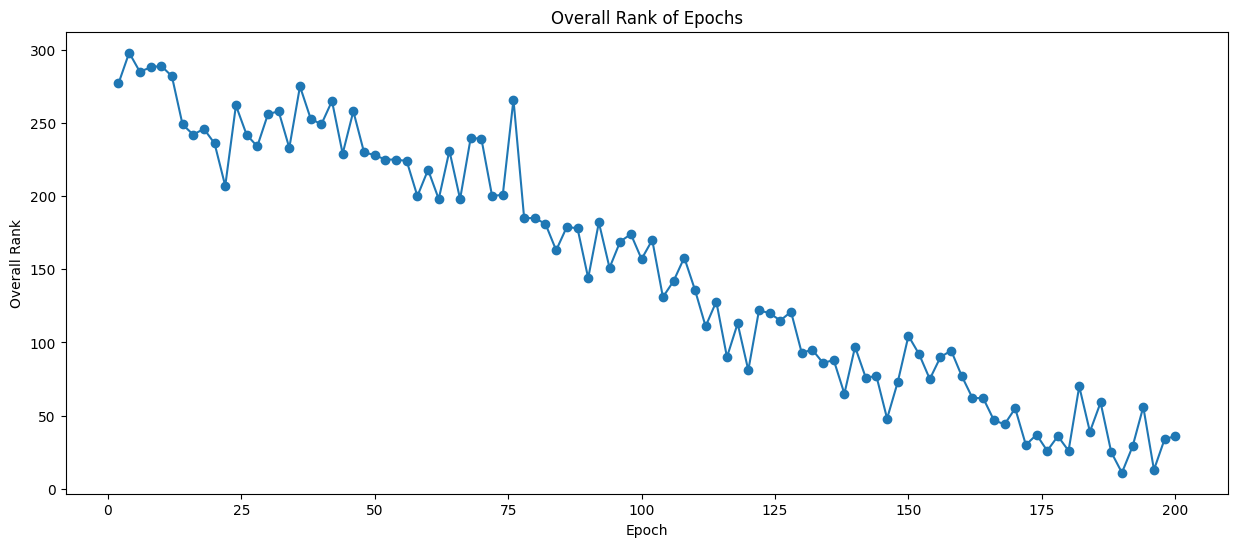

In [38]:
plt.figure(figsize=(15, 6))
plt.plot(list(overall_stage_two_rank.keys()), list(overall_stage_two_rank.values()), marker='o')
plt.xlabel("Epoch")
plt.ylabel("Overall Rank")
plt.title("Overall Rank of Epochs")
plt.show()

In [39]:
best_epoch = min(overall_stage_two_rank, key=overall_stage_two_rank.get)
print("Best epoch:", best_epoch)

Best epoch: 190


In [40]:
#Epoch 190 results 
btob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/BtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
btob50f_best = btob50f_best.sort_values(by='pid')
ctob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/CtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
ctob50f_best = ctob50f_best.sort_values(by='pid')
dtob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage2/DtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
dtob50f_best = dtob50f_best.sort_values(by='pid')

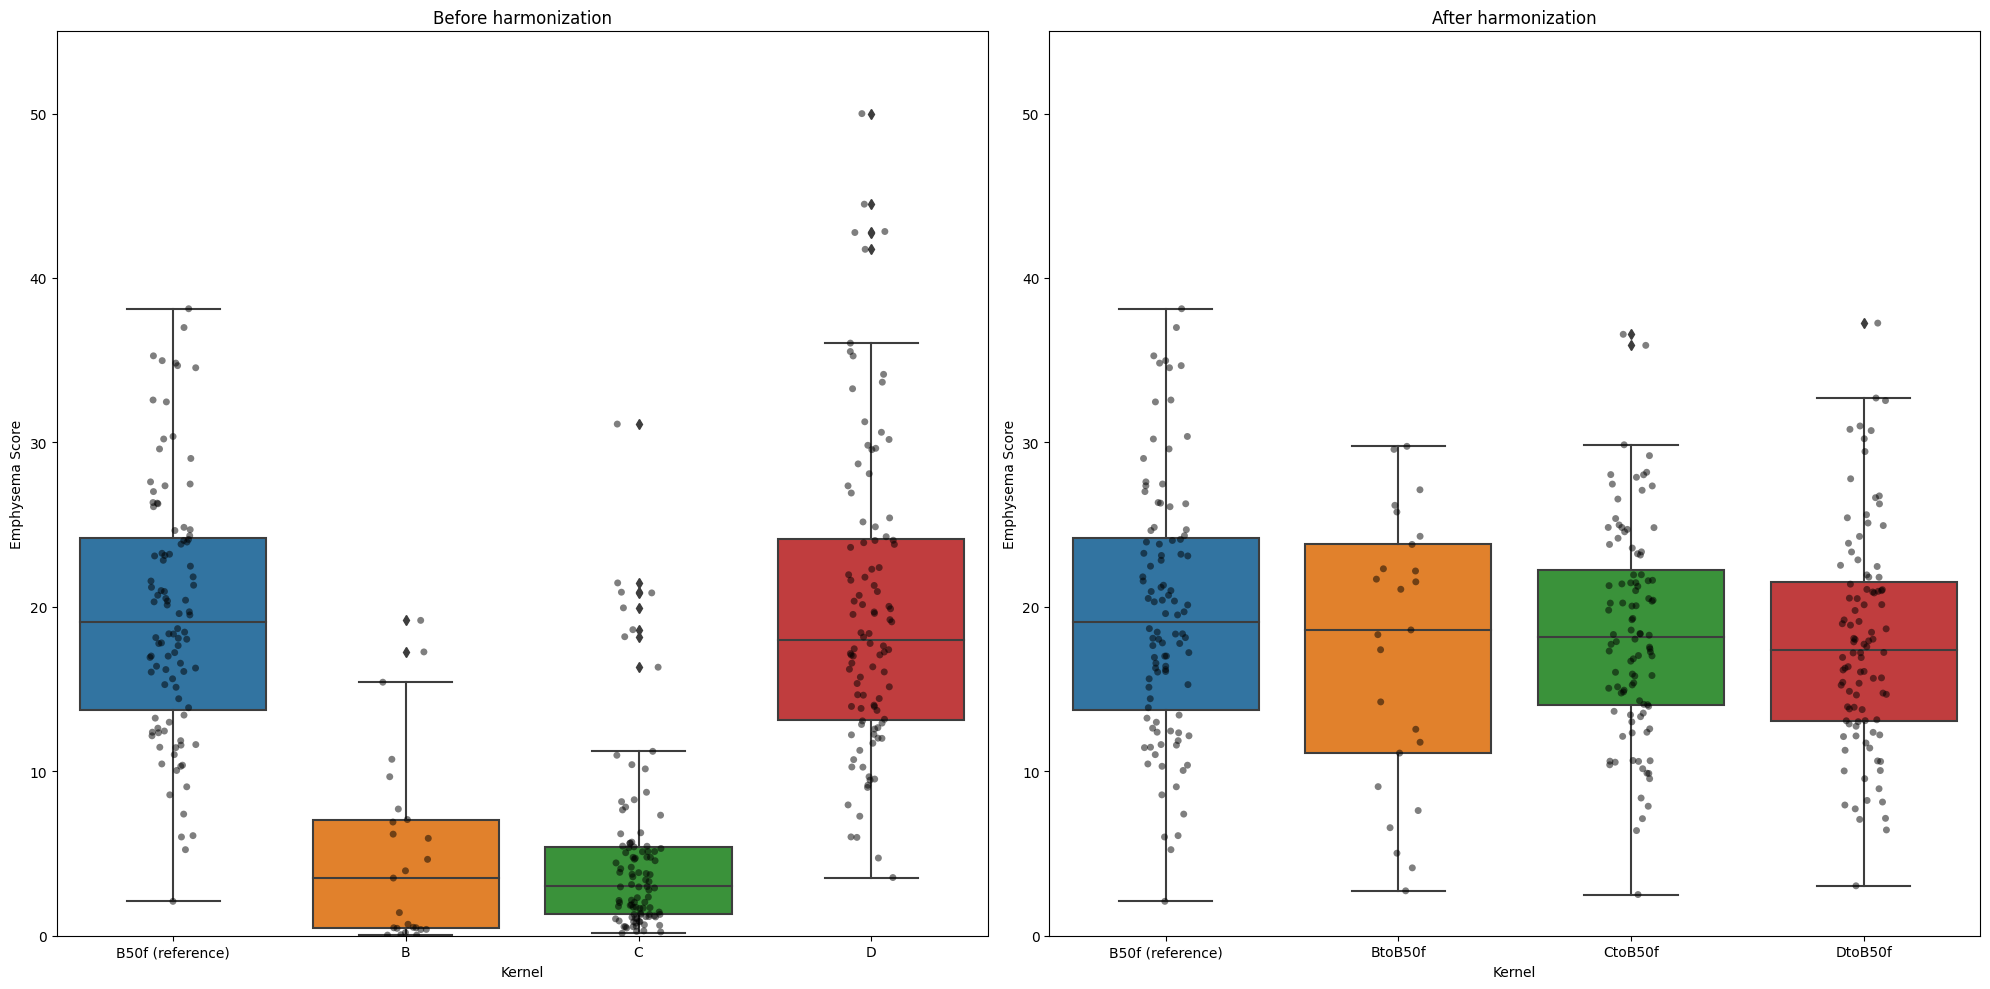

In [41]:
fig, axes = plt.subplots(1,2 , figsize=(20, 10))
sns.boxplot(data=[b50f['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']], ax=axes[0])
sns.stripplot(data=[b50f['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']], ax=axes[0], color='black', alpha=0.5)
axes[0].set_xticks([0, 1, 2, 3])
axes[0].set_xticklabels(['B50f (reference)', 'B', 'C', 'D'])
axes[0].set_title('Before harmonization')
axes[0].set_ylabel('Emphysema Score')
axes[0].set_ylim(0, 55)
axes[0].set_xlabel('Kernel')

sns.boxplot(data=[b50f['emph_score'], btob50f_best['emph_score'], ctob50f_best['emph_score'], dtob50f_best['emph_score']], ax=axes[1])
sns.stripplot(data=[b50f['emph_score'], btob50f_best['emph_score'], ctob50f_best['emph_score'], dtob50f_best['emph_score']], ax=axes[1], color='black', alpha=0.5)
axes[1].set_xticks([0, 1, 2, 3])
axes[1].set_xticklabels(['B50f (reference)', 'BtoB50f', 'CtoB50f', 'DtoB50f'])
axes[1].set_title('After harmonization')
axes[1].set_ylabel('Emphysema Score')
axes[1].set_ylim(0, 55)
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()

# Stage one kernels to a reference Siemens B50f kernel 

In [3]:
b50f = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B30f_B50f/B50f_masked_emphysema/emph.csv")
b50f = b50f.sort_values(by='pid')
b30f = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B30f_B50f/B30f_masked_emphysema/emph.csv")
b30f = b30f.sort_values(by='pid')
b80f = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/B30f_B80f/B80f_masked_emphysema/emph.csv")
b80f = b80f.sort_values(by='pid')
bone = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/STANDARD_BONE/BONE_emphysema/emph.csv")
bone = bone.sort_values(by='pid')
std = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/STANDARD_BONE/STANDARD_emphysema/emph.csv")
std = std.sort_values(by='pid')
lung = pd.read_csv("/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/NLST_harmonization_validation_data/STANDARD_LUNG/LUNG_emphysema/emph.csv")
lung = lung.sort_values(by='pid')

In [4]:
mse_b30ftob50f = {}
kl_bonetob50f = {}
kl_stdtob50f = {}
kl_b80ftob50f = {}
kl_lungtob50f = {}

for i in tqdm(range(2,202,2)):
    b30ftob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/B30ftoB50f_emphysema/epoch_{i}/emph.csv")
    b30ftob50f = b30ftob50f.sort_values(by='pid')
    b80ftob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/B80ftoB50f_emphysema/epoch_{i}/emph.csv")
    b80ftob50f = b80ftob50f.sort_values(by='pid')
    bonetob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/BONEtoB50f_emphysema/epoch_{i}/emph.csv")
    bonetob50f = bonetob50f.sort_values(by='pid')
    stdtob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/STANDARDtoB50f_emphysema/epoch_{i}/emph.csv")
    stdtob50f = stdtob50f.sort_values(by='pid')
    lungtob50f = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/LUNGtoB50f_emphysema/epoch_{i}/emph.csv")
    lungtob50f = lungtob50f.sort_values(by='pid')

    mse_b30ftob50f[i] = mse(b30ftob50f['emph_score'], b50f['emph_score'])
    kl_b80ftob50f[i] = kl_div(b80ftob50f['emph_score'], b50f['emph_score'])
    kl_bonetob50f[i] = kl_div(bonetob50f['emph_score'], b50f['emph_score'])
    kl_stdtob50f[i] = kl_div(stdtob50f['emph_score'], b50f['emph_score'])
    kl_lungtob50f[i] = kl_div(lungtob50f['emph_score'], b50f['emph_score'])

  0%|          | 0/100 [00:00<?, ?it/s]

100%|██████████| 100/100 [00:01<00:00, 52.28it/s]


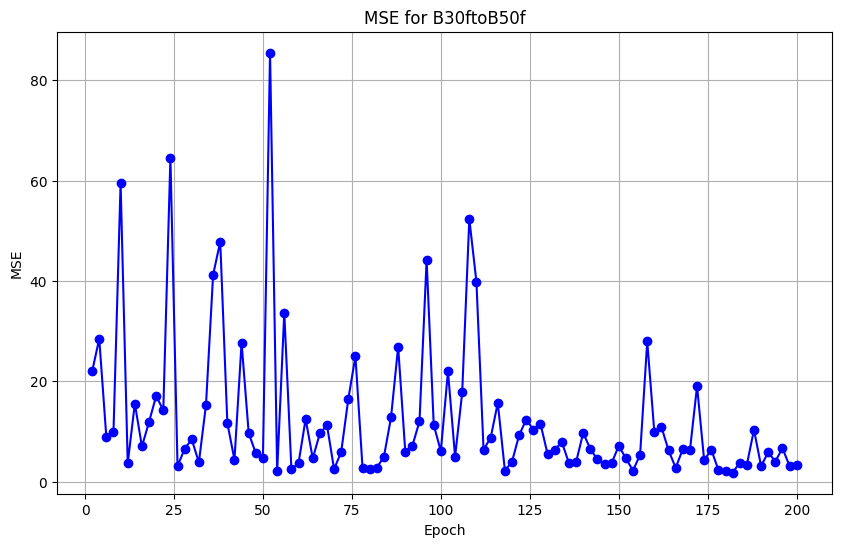

In [5]:
plt.figure(figsize=(10,6))
plt.plot(list(mse_b30ftob50f.keys()), list(mse_b30ftob50f.values()), label='B30ftoB50f', marker = 'o', color='blue')
plt.title('MSE for B30ftoB50f')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid()
plt.show()

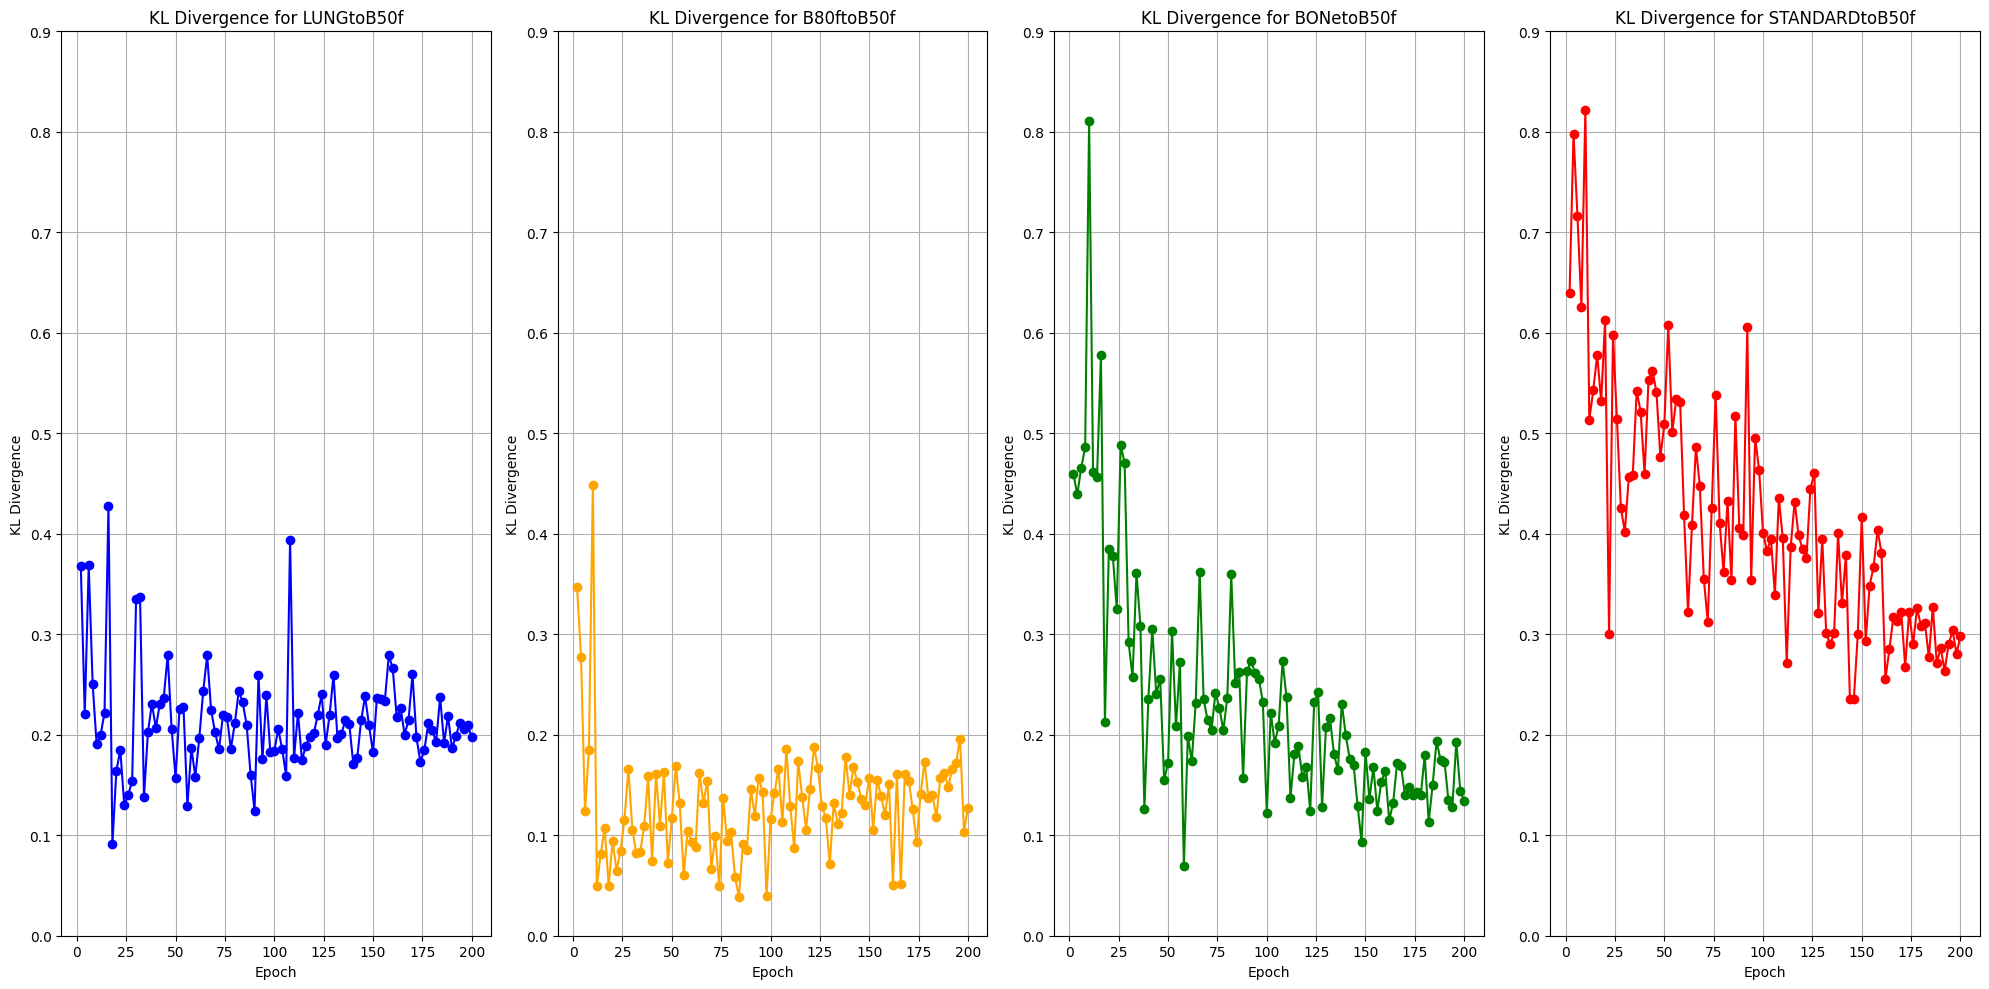

In [6]:
# Make 4 subplots for the kl divergence 
fig, axes = plt.subplots(1, 4, figsize=(20, 10))

axes[0].plot(list(kl_lungtob50f.keys()), list(kl_lungtob50f.values()), label='B30ftoB50f', marker='o', color='blue')
axes[0].set_title('KL Divergence for LUNGtoB50f')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('KL Divergence')
axes[0].set_ylim(0, 0.9)
axes[0].grid()

axes[1].plot(list(kl_b80ftob50f.keys()), list(kl_b80ftob50f.values()), label='B80ftoB50f', marker='o', color='orange')
axes[1].set_title('KL Divergence for B80ftoB50f')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('KL Divergence')
axes[1].set_ylim(0, 0.9)
axes[1].grid()

axes[2].plot(list(kl_bonetob50f.keys()), list(kl_bonetob50f.values()), label='BONetoB50f', marker='o', color='green')
axes[2].set_title('KL Divergence for BONetoB50f')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('KL Divergence')
axes[2].set_ylim(0, 0.9)
axes[2].grid()

axes[3].plot(list(kl_stdtob50f.keys()), list(kl_stdtob50f.values()), label='STANDARDtoB50f', marker='o', color='red')
axes[3].set_title('KL Divergence for STANDARDtoB50f')
axes[3].set_xlabel('Epoch')
axes[3].set_ylabel('KL Divergence')
axes[3].set_ylim(0, 0.9)
axes[3].grid()

plt.tight_layout()
plt.show()

In [7]:
mse_b30ftob50f_ranks = rankdata(list(mse_b30ftob50f.values()))
kl_b80ftob50f_ranks = rankdata(list(kl_b80ftob50f.values()))
kl_bonetob50f_ranks = rankdata(list(kl_bonetob50f.values()))
kl_stdtob50f_ranks = rankdata(list(kl_stdtob50f.values()))

mse_b30ftob50f_rank = {list(mse_b30ftob50f.keys())[i]: mse_b30ftob50f_ranks[i] for i in range(len(mse_b30ftob50f_ranks))}
kl_b80ftob50f_rank = {list(kl_b80ftob50f.keys())[i]: kl_b80ftob50f_ranks[i] for i in range(len(kl_b80ftob50f_ranks))}
kl_bonetob50f_rank = {list(kl_bonetob50f.keys())[i]: kl_bonetob50f_ranks[i] for i in range(len(kl_bonetob50f_ranks))}
kl_stdtob50f_rank = {list(kl_stdtob50f.keys())[i]: kl_stdtob50f_ranks[i] for i in range(len(kl_stdtob50f_ranks))}

mse_b30ftob50f_rank = dict(sorted(mse_b30ftob50f_rank.items()))
kl_b80ftob50f_rank = dict(sorted(kl_b80ftob50f_rank.items()))
kl_bonetob50f_rank = dict(sorted(kl_bonetob50f_rank.items()))
kl_stdtob50f_rank = dict(sorted(kl_stdtob50f_rank.items()))

In [26]:
overall_stage_one_rank = {}

for key in mse_b30ftob50f_rank.keys():
    # overall_stage_one_rank[key] = 0.1*mse_b30ftob50f_rank[key] + 0.3*kl_b80ftob50f_rank[key] + 0.3*kl_bonetob50f_rank[key] + 0.3*kl_stdtob50f_rank[key]
    overall_stage_one_rank[key] = mse_b30ftob50f_rank[key] + kl_b80ftob50f_rank[key] + kl_bonetob50f_rank[key] + kl_stdtob50f_rank[key]


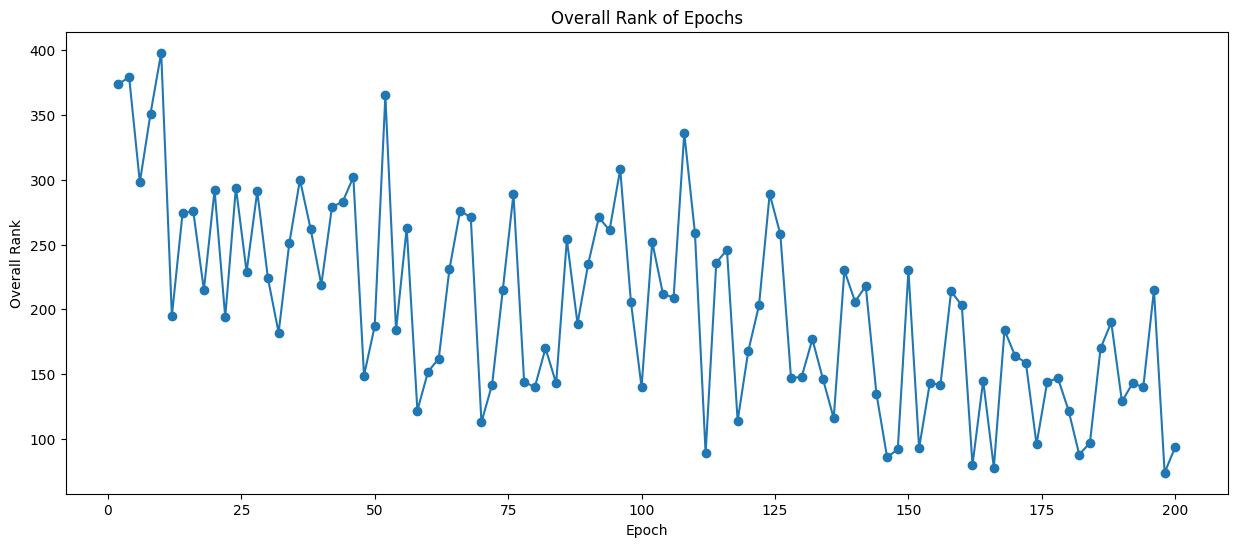

In [27]:
plt.figure(figsize=(15, 6))
plt.plot(list(overall_stage_one_rank.keys()), list(overall_stage_one_rank.values()), marker='o')
plt.xlabel("Epoch")
plt.ylabel("Overall Rank")
plt.title("Overall Rank of Epochs")
plt.show()

In [28]:
best_epoch = min(overall_stage_one_rank, key=overall_stage_one_rank.get)
print(f"The best epoch is: {best_epoch} with rank {overall_stage_one_rank[best_epoch]}")

The best epoch is: 198 with rank 74.0


In [29]:
#Epoch 198 results 
b30ftob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/B30ftoB50f_emphysema/epoch_{best_epoch}/emph.csv")
b30ftob50f_best = b30ftob50f_best.sort_values(by='pid')
b80ftob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/B80ftoB50f_emphysema/epoch_{best_epoch}/emph.csv")
b80ftob50f_best = b80ftob50f_best.sort_values(by='pid')
bonetob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/BONEtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
bonetob50f_best = bonetob50f_best.sort_values(by='pid')
stdtob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/STANDARDtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
stdtob50f_best = stdtob50f_best.sort_values(by='pid')
lungtob50f_best = pd.read_csv(f"/valiant02/masi/krishar1/NLST_supplementary_grants/validation_multipath_NLST/validation_stage1/LUNGtoB50f_emphysema/epoch_{best_epoch}/emph.csv")
lungtob50f_best = lungtob50f_best.sort_values(by='pid')

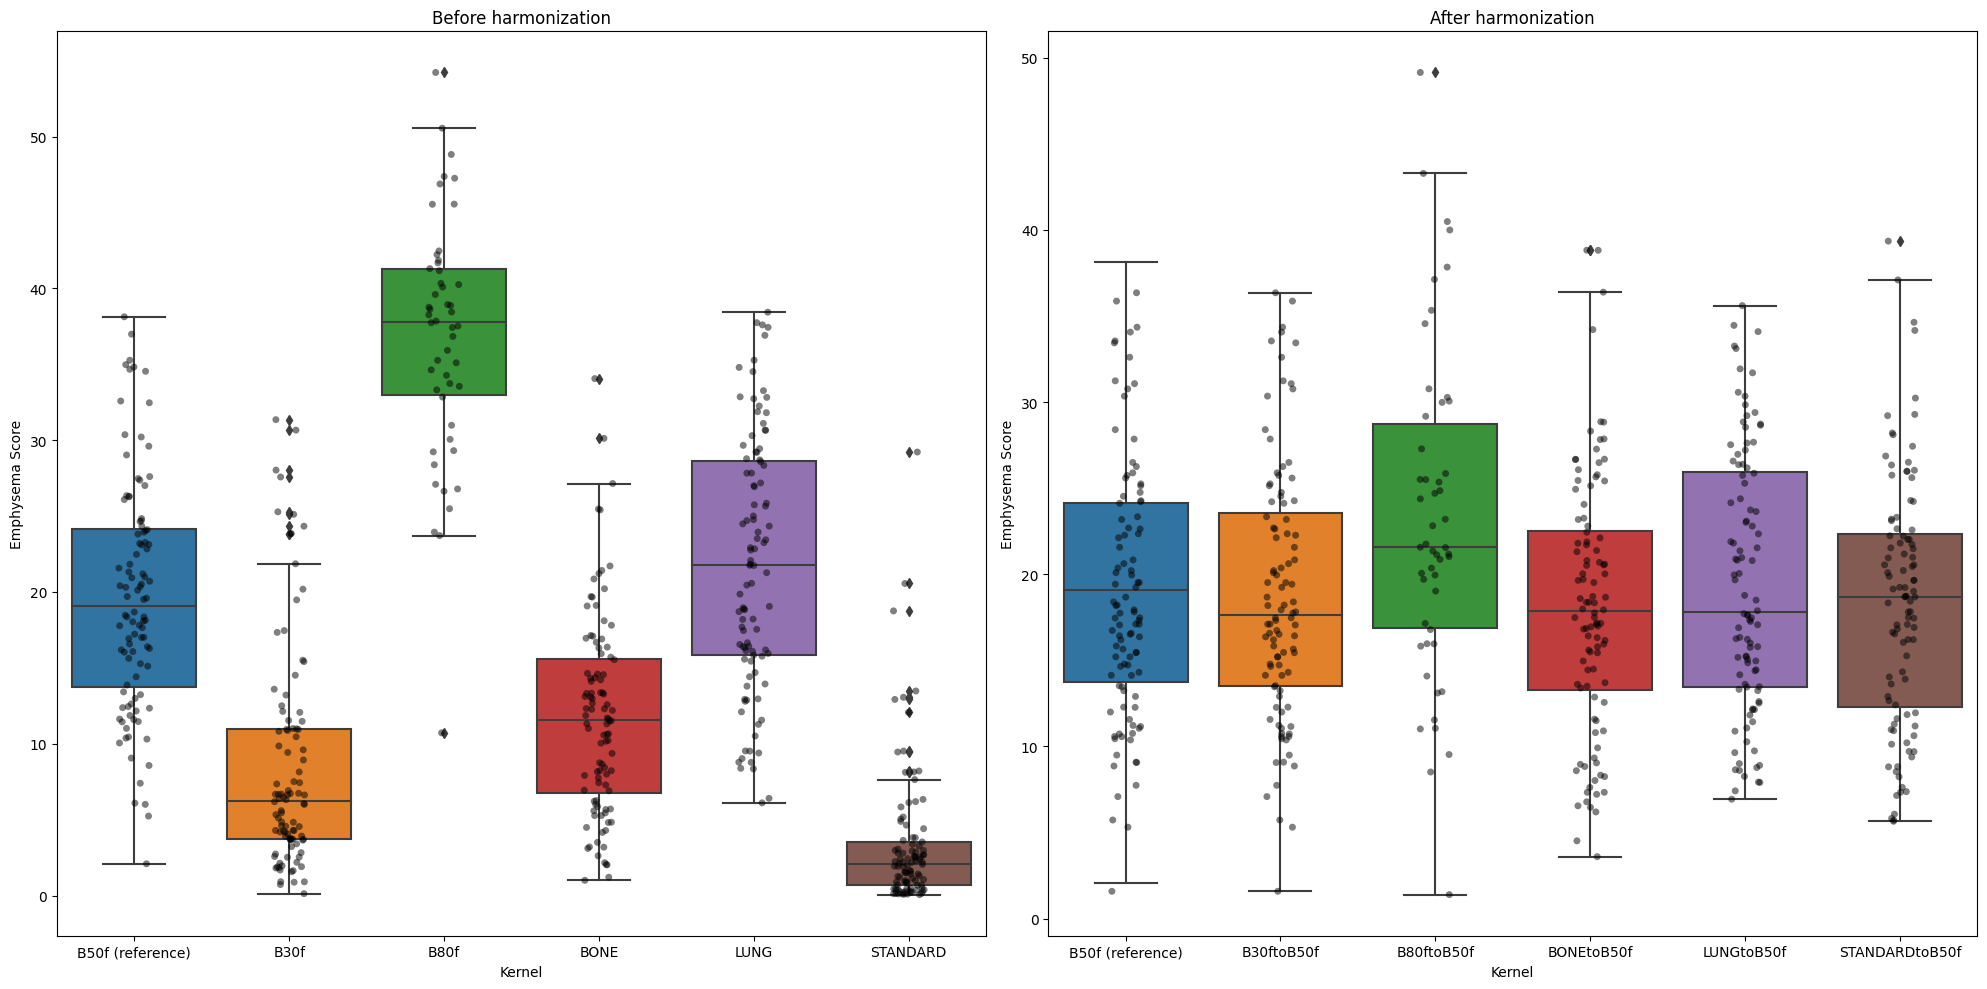

In [30]:
fig, axes = plt.subplots(1,2 , figsize=(20, 10))
sns.boxplot(data=[b50f['emph_score'], b30f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std['emph_score']],
            ax=axes[0])
sns.stripplot(data=[b50f['emph_score'], b30f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std['emph_score']],
              ax=axes[0], color='black', alpha=0.5, jitter=True)
axes[0].set_xticks([0, 1, 2, 3, 4, 5])
axes[0].set_xticklabels(['B50f (reference)', 'B30f', 'B80f', 'BONE', 'LUNG', 'STANDARD'])
axes[0].set_title('Before harmonization')
axes[0].set_ylabel('Emphysema Score')
axes[0].set_xlabel('Kernel')

sns.boxplot(data=[b50f['emph_score'], b30ftob50f_best['emph_score'], b80ftob50f_best['emph_score'], bonetob50f_best['emph_score'], lungtob50f_best['emph_score'], stdtob50f_best['emph_score']],
            ax=axes[1])
sns.stripplot(data=[b30ftob50f_best['emph_score'], b30ftob50f_best['emph_score'], b80ftob50f_best['emph_score'], bonetob50f_best['emph_score'], lungtob50f_best['emph_score'], stdtob50f_best['emph_score']],
              ax=axes[1], color='black', alpha=0.5, jitter=True)
axes[1].set_xticks([0, 1, 2, 3, 4, 5])
axes[1].set_xticklabels(['B50f (reference)', 'B30ftoB50f', 'B80ftoB50f', 'BONEtoB50f', 'LUNGtoB50f', 'STANDARDtoB50f'])
axes[1].set_title('After harmonization')
axes[1].set_ylabel('Emphysema Score')
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()

In [31]:
#Stat test mann whitney between reference and best epoch
import scipy.stats as stats

b30ftob50f_stat, p_b30ftob50f = stats.mannwhitneyu(b50f['emph_score'], b30ftob50f_best['emph_score'])
bonetob50f_stat, p_bonetob50f = stats.mannwhitneyu(b50f['emph_score'], bonetob50f_best['emph_score'])
stdtob50f_stat, p_stdtob50f = stats.mannwhitneyu(b50f['emph_score'], stdtob50f_best['emph_score'])
b80ftob50f_stat, p_b80ftob50f = stats.mannwhitneyu(b50f['emph_score'], b80ftob50f_best['emph_score'])
lungtob50f_stat, p_lungtob50f = stats.mannwhitneyu(b50f['emph_score'], lungtob50f_best['emph_score'])

print(f"B30ftoB50f: stat={b30ftob50f_stat}, p-value={p_b30ftob50f}")
print(f"BONetoB50f: stat={bonetob50f_stat}, p-value={p_bonetob50f}")
print(f"STDtoB50f: stat={stdtob50f_stat}, p-value={p_stdtob50f}")
print(f"B80ftoB50f: stat={b80ftob50f_stat}, p-value={p_b80ftob50f}")
print(f"LungtoB50f: stat={lungtob50f_stat}, p-value={p_lungtob50f}")

B30ftoB50f: stat=5401.0, p-value=0.32778890500440383
BONetoB50f: stat=5555.0, p-value=0.17546244064801408
STDtoB50f: stat=5459.0, p-value=0.26258858123082096
B80ftoB50f: stat=1947.0, p-value=0.027618018800093475
LungtoB50f: stat=5117.0, p-value=0.7759086187894354


In [42]:
btob50f_stat, p_btob50f = stats.mannwhitneyu(b50f['emph_score'], btob50f_best['emph_score'])
ctob50f_stat, p_ctob50f = stats.mannwhitneyu(b50f['emph_score'], ctob50f_best['emph_score'])
dtob50f_stat, p_dtob50f = stats.mannwhitneyu(b50f['emph_score'], dtob50f_best['emph_score'])

print(f"BtoB50f: stat={btob50f_stat}, p-value={p_btob50f}")
print(f"CtoB50f: stat={ctob50f_stat}, p-value={p_ctob50f}")
print(f"DtoB50f: stat={dtob50f_stat}, p-value={p_dtob50f}")

BtoB50f: stat=1387.0, p-value=0.39951021504020545
CtoB50f: stat=5403.0, p-value=0.32537911162752287
DtoB50f: stat=5676.0, p-value=0.0988388345899766


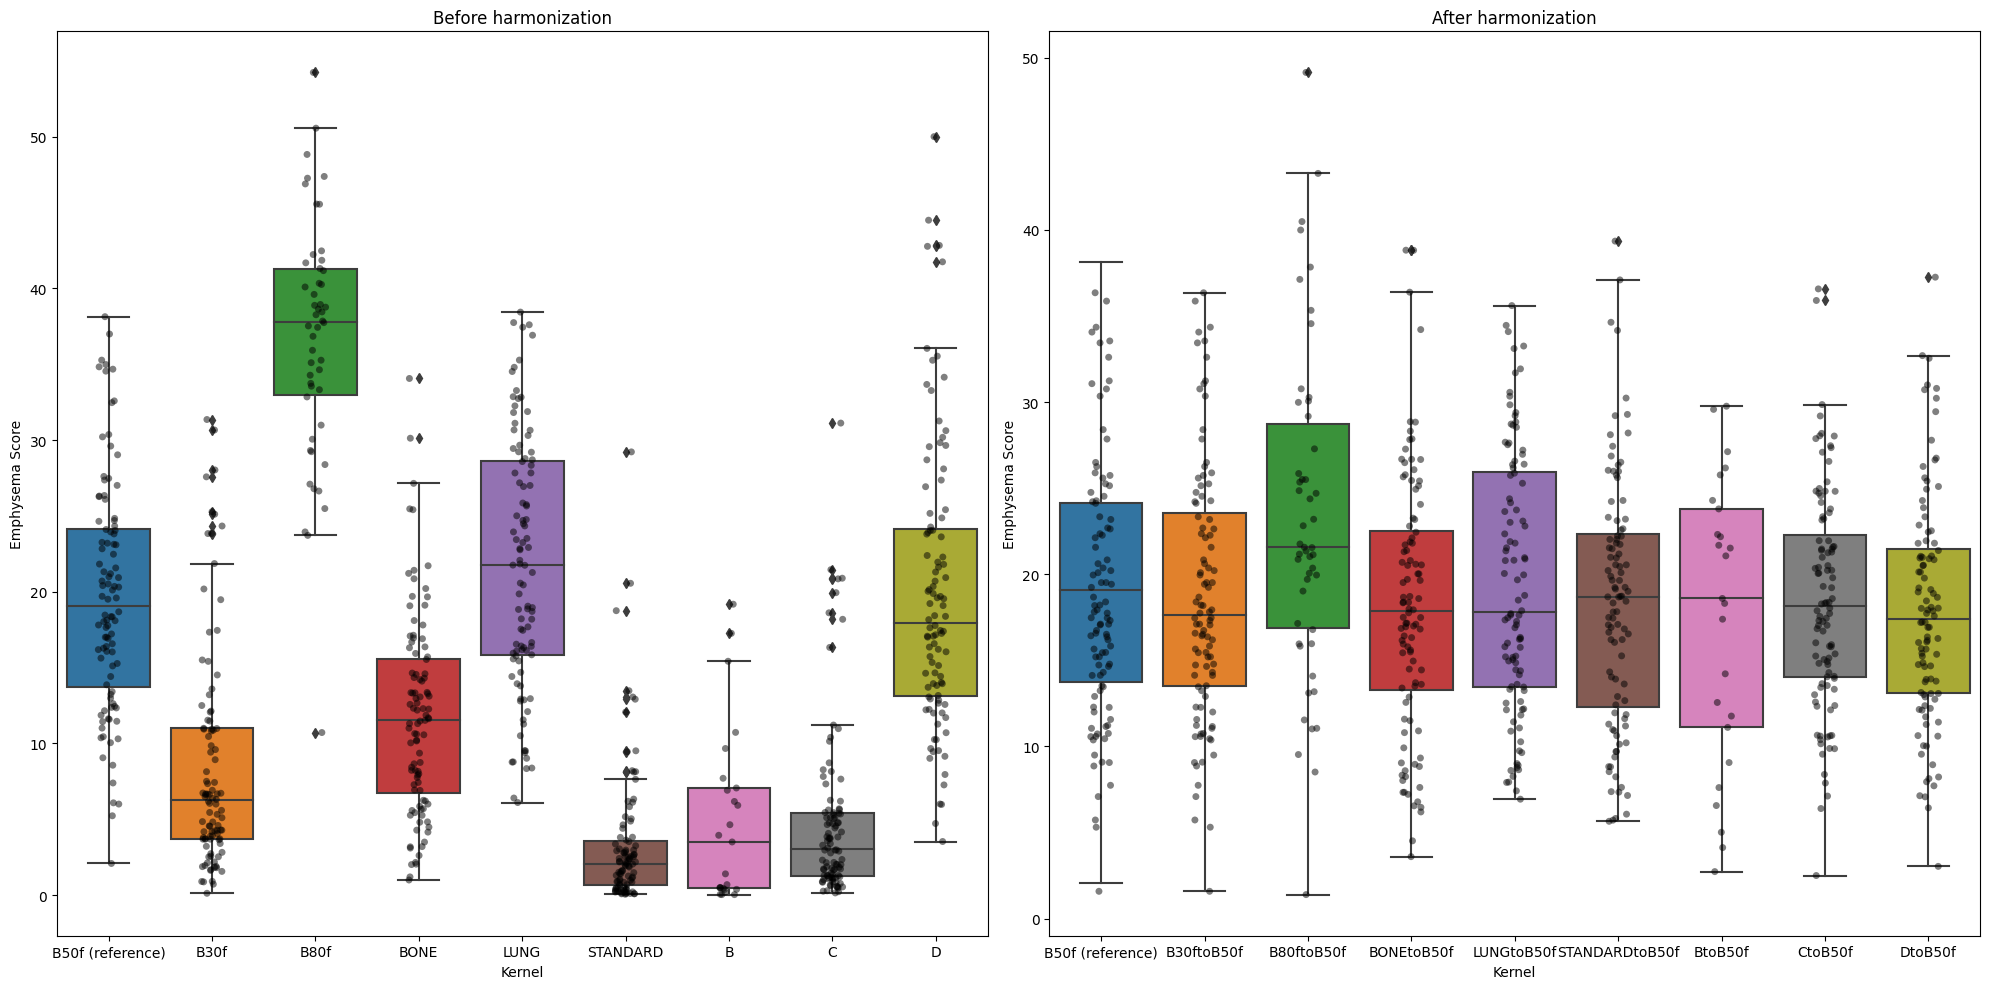

In [44]:
fig, axes = plt.subplots(1,2 , figsize=(20, 10))
sns.boxplot(data=[b50f['emph_score'], b30f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']],
            ax=axes[0])
sns.stripplot(data=[b50f['emph_score'], b30f['emph_score'], b80f['emph_score'], bone['emph_score'], lung['emph_score'], std['emph_score'], b['emph_score'], c['emph_score'], d_c['emph_score']],
              ax=axes[0], color='black', alpha=0.5, jitter=True)
axes[0].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])
axes[0].set_xticklabels(['B50f (reference)', 'B30f', 'B80f', 'BONE', 'LUNG', 'STANDARD', 'B', 'C', 'D'])
axes[0].set_title('Before harmonization')
axes[0].set_ylabel('Emphysema Score')
axes[0].set_xlabel('Kernel')

sns.boxplot(data=[b50f['emph_score'], b30ftob50f_best['emph_score'], b80ftob50f_best['emph_score'], bonetob50f_best['emph_score'], lungtob50f_best['emph_score'], stdtob50f_best['emph_score'], btob50f_best['emph_score'], ctob50f_best['emph_score'], dtob50f_best['emph_score']],
            ax=axes[1])
sns.stripplot(data=[b30ftob50f_best['emph_score'], b30ftob50f_best['emph_score'], b80ftob50f_best['emph_score'], bonetob50f_best['emph_score'], lungtob50f_best['emph_score'], stdtob50f_best['emph_score'], btob50f_best['emph_score'], ctob50f_best['emph_score'], dtob50f_best['emph_score']],
              ax=axes[1], color='black', alpha=0.5, jitter=True)
axes[1].set_xticks([0, 1, 2, 3, 4, 5, 6, 7, 8])
axes[1].set_xticklabels(['B50f (reference)', 'B30ftoB50f', 'B80ftoB50f', 'BONEtoB50f', 'LUNGtoB50f', 'STANDARDtoB50f', 'BtoB50f', 'CtoB50f', 'DtoB50f'])
axes[1].set_title('After harmonization')
axes[1].set_ylabel('Emphysema Score')
axes[1].set_xlabel('Kernel')

plt.tight_layout()
plt.show()